## Q8: Game of Life visualization

In [1]:
import game_of_life_funcs as f
import importlib
importlib.reload(f)
import numpy as np

For now I still can't set up a configuration of the game that lasts forever, so there is no point in doing a lot of iterations because the system dies anyway

In [2]:
generator = np.random.default_rng()
my_grid = generator.integers(low = 0, high=1, endpoint = True, size = (100,100))
f.play_life_game_wplots(my_grid, 100)

Ok so from what I understood there are initial conditions one can set on the game of life that lead to cool patterns/the game technically lives forever. The easiest one I could find is called glider runner. Now i have looked everywhere and couldn't find an efficient way to code a matrix that has the initial setting of a spaceship, so we'll do it manually. This video : https://www.youtube.com/watch?v=v8wu2pXRq2Y does it, so I'll just create a 2D array of zeros and manually insert 1s where he filled in the little squares

In [47]:
my_grid = np.zeros((100,100))
cols = [10,10,11,11,20,20,20,21,21,22,22,23,23,24,25,25,26,26,26,27,30,30,30,31,31,31,32,32,34,34,34,34,44,44,45,45]
rows = [10,11,10,11,10,11,12,9,13,8,14,8,14,11,9,13,10,11,12,11,8,9,10,8,9,10,7,11,6,7,11,12,8,9,8,9]
my_grid[rows,cols] = 1
f.play_life_game_wplots(my_grid, 100)

ok didn't work, either something is wrong with my rules (likely), or i drew it wrong (also likely)

## Q3: A perfect circle

For an angle $\theta$ in the range $\theta \in [0, 2\pi]$, the polar equations of a circle of radius $R$ are:

$$x = R\cos(\theta)$$

$$y = R\sin(\theta)$$

We want to draw a circle.   

  * Create an array to hold the theta values&mdash;the more we use, the smoother the circle will be
  * Create `x` and `y` arrays from `theta` for your choice of $R$
  * Plot `y` vs. `x`
  
Now, look up the matplotlib `fill()` function, and draw a circle filled in with a solid color.

In [62]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as m
import numpy as np

In [63]:
plt.style.use("fivethirtyeight")
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Courier"
})

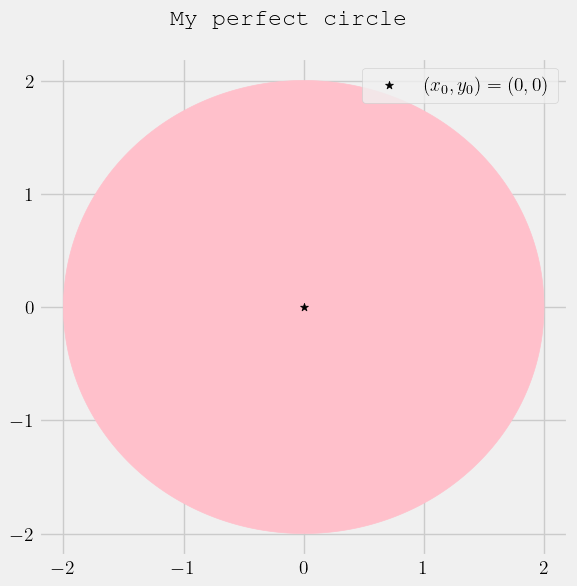

In [64]:
theta = np.linspace(0, 2*np.pi, 500)
x = np.array([2*np.cos(i) for i in theta])
y = np.array([2*np.sin(i) for i in theta])

fig = plt.figure(figsize = (6,6))
fig.suptitle(r"My perfect circle")
ax = fig.add_subplot(111)
ax.fill(x,y, color = "pink")
ax.scatter(0, 0, label = r'$(x_0,y_0) = (0,0)$', marker= '*', color = "black")
ax.set_xticks([-2,-1,0,1,2])
ax.set_yticks([-2,-1,0,1,2])
ax.legend(loc = "upper right")
fig.tight_layout()


Generalize your circle drawing commands to produce a function, 
```
draw_circle(x0, y0, R, color)
```
that draws the circle.  Here, `(x0, y0)` is the center of the circle, `R` is the radius, and `color` is the color of the circle.  

Now randomly draw 10 circles at different locations, with random radii, and random colors on the same plot.

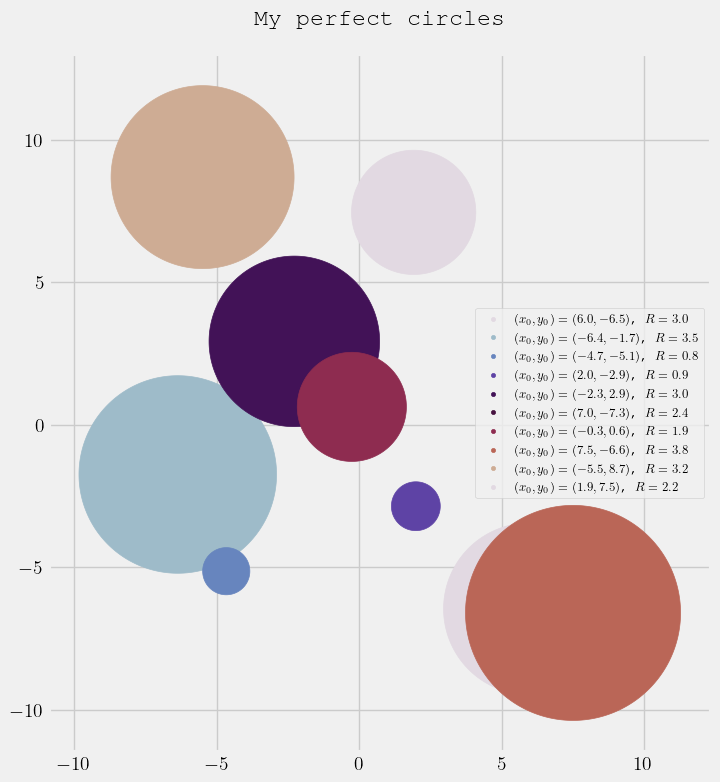

In [ ]:
fig = plt.figure(figsize = (8,8))
fig.suptitle(r"My perfect-ish circles")
ax = fig.add_subplot(111)
ax.set_aspect("equal") 

#the bounds of this random generator can, of course, be changed
x0_vals = [np.random.uniform(-10, 10) for _ in range(10)]
y0_vals = [np.random.uniform(-10, 10) for _ in range(10)]
radii_vals = [np.random.uniform(0.5, 4) for _ in range(10)]
cmap = m.colormaps['twilight']
colors = cmap(np.linspace(0, 1, 10))

def draw_circle(x0, y0, R, color):

    x = np.array([x0 + R*np.cos(i) for i in theta])
    y = np.array([y0 + R*np.sin(i) for i in theta])

    ax.fill(x , y , color = color)
    ax.scatter(x0, y0, label = rf"$(x_0,y_0) = ({x0:.1f},{y0:.1f})$, $R = {R:.1f}$", marker= '.', color = color)
    ax.set_xticks(np.linspace(-10,10,5))
    ax.set_yticks(np.linspace(-10,10,5))

#this loop is inevitable, right?
_ = [draw_circle(x0, y0, r, c) for x0, y0, r, c in zip(x0_vals, y0_vals, radii_vals, colors)]
ax.legend(loc = "best", fontsize=9)
fig.tight_layout()
